# Краткий анализ данных

Данные: бессрочный фьючерс ETH, 19–21 марта 2026 года.

Цель: проверить данные перед созданием исторической проверки стратегии. Стакан читается порциями. В память попадает только один снимок в секунду.

In [1]:
from pathlib import Path
import os

ROOT = next(p for p in (Path.cwd(), Path.cwd().parent) if (p / 'data/extracted/take-home-project/data').exists())
DATA = ROOT / 'data/extracted/take-home-project/data'
os.environ.setdefault('MPLCONFIGDIR', str(ROOT / '.mplconfig'))

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.diagnostic import het_arch
from statsmodels.stats.stattools import jarque_bera
from statsmodels.tsa.stattools import adfuller

ALPHA = 0.05
BATCH_SIZE = 100_000
FUNDING_HOURS = 8
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)

## Загрузка

Стакан большой, поэтому читаем только время, лучшие цены и объёмы первых пяти уровней.

In [2]:
def read_book():
    parts = []
    fast_parts = []
    bid_qty = [f'bid_qty_{i}' for i in range(1, 6)]
    ask_qty = [f'ask_qty_{i}' for i in range(1, 6)]
    columns = ['datetime', 'bid_price_1', 'ask_price_1', *bid_qty, *ask_qty]

    for path in sorted((DATA / 'orderbook').glob('*.parquet')):
        for batch in pq.ParquetFile(path).iter_batches(columns=columns, batch_size=BATCH_SIZE):
            x = batch.to_pandas()
            bid_depth = x[bid_qty].sum(axis=1)
            ask_depth = x[ask_qty].sum(axis=1)
            x['second'] = x['datetime'].dt.floor('1s')
            x['tenth'] = x['datetime'].dt.floor('100ms')
            x['mid'] = (x['bid_price_1'] + x['ask_price_1']) / 2
            x['spread'] = x['ask_price_1'] - x['bid_price_1']
            x['pressure'] = (bid_depth - ask_depth) / (bid_depth + ask_depth)
            parts.append(x.groupby('second', sort=False).tail(1)[['datetime', 'second', 'mid', 'spread', 'pressure']])
            fast_parts.append(x.groupby('tenth', sort=False).tail(1)[['datetime', 'tenth', 'mid', 'pressure']])

    book = pd.concat(parts, ignore_index=True).sort_values('datetime')
    book = book.groupby('second', sort=False).tail(1)
    fast_book = pd.concat(fast_parts, ignore_index=True).sort_values('datetime')
    fast_book = fast_book.groupby('tenth', sort=False).tail(1)
    return book.set_index('datetime').drop(columns='second'), fast_book.set_index('datetime').drop(columns='tenth')


def read_small(folder, columns):
    paths = sorted((DATA / folder).glob('*.parquet'))
    return pd.concat([pd.read_parquet(path, columns=columns) for path in paths], ignore_index=True).sort_values('datetime')


book, fast_book = read_book()
trades = read_small('trades', ['datetime', 'size'])
funding = read_small('fundings', ['datetime', 'funding_rate'])

mid_1m = book['mid'].resample('1min').last().dropna()
mid_10s = book['mid'].resample('10s').last().ffill(limit=3).dropna()
returns = np.log(mid_10s).diff().dropna()
funding['annual_pct'] = funding['funding_rate'] * (24 / FUNDING_HOURS) * 365 * 100

print(f'Стакан после сжатия: {len(book):,} строк, {book.memory_usage(deep=True).sum() / 2**20:.1f} МБ')
print(f'Стакан для коротких горизонтов: {len(fast_book):,} строк, {fast_book.memory_usage(deep=True).sum() / 2**20:.1f} МБ')
print(f'Сделки: {len(trades):,} строк')
print(f'Фандинг: {len(funding):,} строк')

Стакан после сжатия: 258,932 строк, 7.9 МБ
Стакан для коротких горизонтов: 2,169,564 строк, 49.7 МБ
Сделки: 70,556 строк
Фандинг: 12,902 строк


## Проверка данных

In [3]:
raw_book_rows = sum(pq.ParquetFile(path).metadata.num_rows for path in (DATA / 'orderbook').glob('*.parquet'))
quality = pd.Series({
    'Строк стакана в исходных данных': raw_book_rows,
    'Строк после сжатия': len(book),
    'Начало': book.index.min(),
    'Конец': book.index.max(),
    'Пропуски': int(book.isna().sum().sum()),
    'Нулевой или отрицательный спред': int((book['spread'] <= 0).sum()),
})
display(quality.to_frame('Значение'))
print('Вывод: пропусков и некорректного спреда нет. Данные пригодны для дальнейшего анализа.')

,Значение
Строк стакана в исходных данных,3581577
Строк после сжатия,258932
Начало,2026-03-19 00:00:00.940486781
Конец,2026-03-21 23:59:56.264153377
Пропуски,0
Нулевой или отрицательный спред,0


Вывод: пропусков и некорректного спреда нет. Данные пригодны для дальнейшего анализа.


## Цена и спред

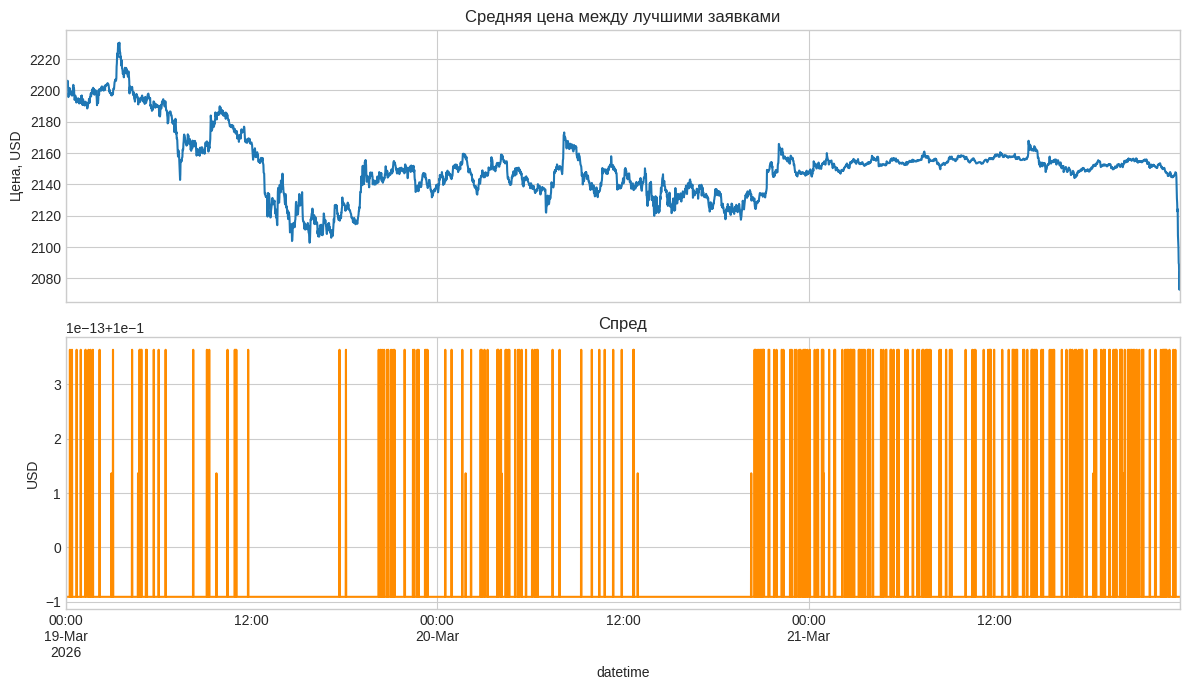

In [4]:
minute = book.resample('1min').agg({'mid': 'last', 'spread': 'median'}).dropna()
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
minute['mid'].plot(ax=axes[0], title='Средняя цена между лучшими заявками')
minute['spread'].plot(ax=axes[1], color='darkorange', title='Спред')
axes[0].set_ylabel('Цена, USD')
axes[1].set_ylabel('USD')
plt.tight_layout()
plt.show()

## Обвал в конце

Минутная доходность:

$$r_t=\ln(P_t/P_{t-1}).$$

,Значение
Самая резкая минута,2026-03-21 23:51:00
"Доходность за минуту, %",-0.789304
"Изменение в выделенном окне, %",-2.842961


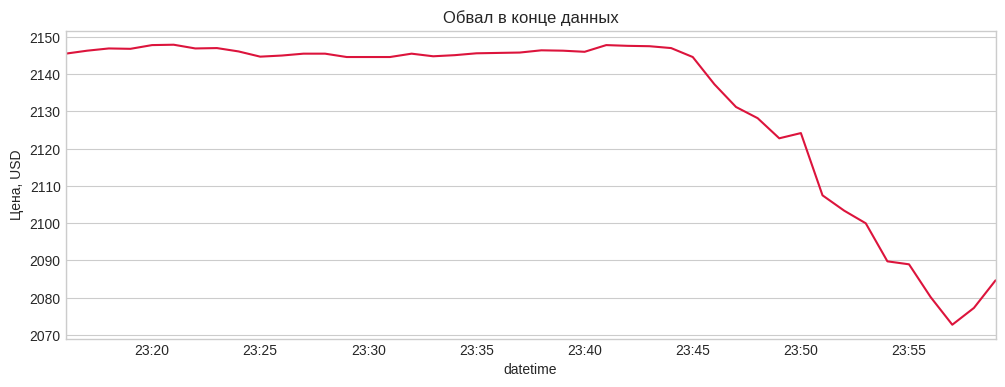

Вывод: обвал не удаляем. Он нужен как проверка стратегии в стрессовой ситуации.


In [5]:
return_1m = np.log(mid_1m).diff().dropna()
crash_time = return_1m.abs().idxmax()
start = max(crash_time - pd.Timedelta('15min'), mid_1m.index.min())
end = min(crash_time + pd.Timedelta('15min'), mid_1m.index.max())
change = 100 * (mid_1m.loc[start:end].iloc[-1] / mid_1m.loc[start:end].iloc[0] - 1)

display(pd.Series({
    'Самая резкая минута': crash_time,
    'Доходность за минуту, %': 100 * return_1m.loc[crash_time],
    'Изменение в выделенном окне, %': change,
}).to_frame('Значение'))

mid_1m.loc[start - pd.Timedelta('20min'):end].plot(color='crimson', title='Обвал в конце данных')
plt.ylabel('Цена, USD')
plt.show()
print('Вывод: обвал не удаляем. Он нужен как проверка стратегии в стрессовой ситуации.')

## Давление стакана

Складываем объёмы первых пяти уровней покупки и продажи:

$$I_t=\frac{V_t^{buy}-V_t^{sell}}{V_t^{buy}+V_t^{sell}}.$$

$I_t>0$ означает, что на стороне покупки стоит больше объёма.

Для коротких горизонтов стакан сжимается до одного снимка за 0.1 секунды. Проверяем 0.3, 0.5, 1, 5, 10, 30, 60 и 300 секунд. Для настройки простой зависимости $r=a+bI$ используем 19–20 марта, а 21 марта — только для проверки. Дополнительно проверяем простое правило `знак давления → направление цены` отдельно на каждом дне. Точность считаем лишь для интервалов, где цена действительно изменилась.

,"Горизонт, секунд",Ранговая корреляция,"Объяснённая доля, %","Верное направление при движении, %","Простой прогноз при движении, %","Интервалы с движением, %"
0,0.3,0.155114,-7.035089,87.939959,50.789337,2.685982
1,0.5,0.182787,-7.700837,87.102750,50.676927,4.064080
2,1.0,0.228362,-7.216832,85.571569,50.704225,7.072696
3,5.0,0.332924,0.365009,79.140811,50.381862,24.258916
4,10.0,0.342647,2.488237,73.939394,50.212121,38.203288
5,30.0,0.302722,2.631124,66.408669,49.329205,67.315040
6,60.0,0.207944,2.122112,59.612142,49.662732,82.418346
7,300.0,0.131794,-0.258617,49.090909,49.090909,95.818815


,День,"Горизонт, секунд",Ранговая корреляция,"Верное направление при движении, %","Интервалы с движением, %"
0,2026-03-19,0.3,0.299879,83.580013,13.730394
1,2026-03-19,0.5,0.318792,79.717823,20.107456
2,2026-03-19,1.0,0.329576,74.503549,32.303185
3,2026-03-19,5.0,0.235527,62.694932,71.266497
4,2026-03-19,10.0,0.179093,59.010169,85.368677
5,2026-03-19,30.0,0.103323,53.871201,96.005557
6,2026-03-19,60.0,0.097742,55.182273,97.220292
7,2026-03-19,300.0,0.037767,53.380783,97.909408
8,2026-03-20,0.3,0.286804,86.284886,11.037480
9,2026-03-20,0.5,0.309983,82.693800,16.430053


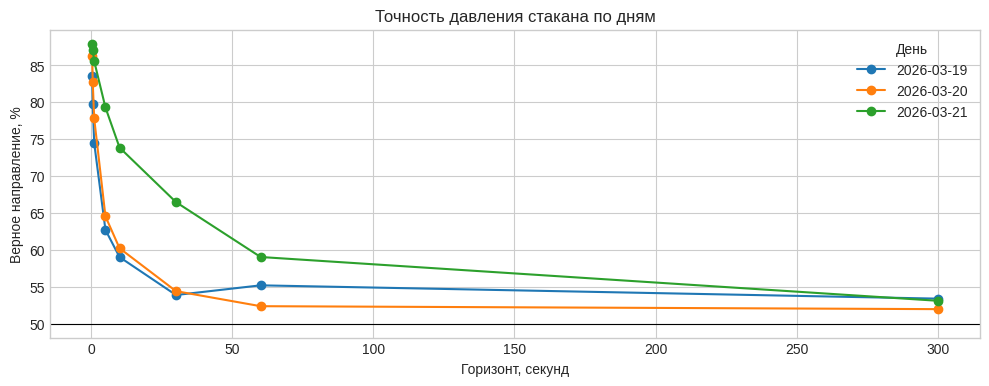

Точность на 0.3 секунды при наличии движения — 2026-03-19: 83.6%, 2026-03-20: 86.3%, 2026-03-21: 87.9%.
Вывод: давление хорошо угадывает сторону ближайшего движения, особенно на 0.3–1 секунде.
Но цена часто не меняется, а размер движения на коротком горизонте модель предсказывает плохо.
К пяти минутам преимущество почти исчезает. Давление используем только как небольшой сдвиг котировок.


In [6]:
horizons = (0.3, 0.5, 1, 5, 10, 30, 60, 300)
split_date = pd.Timestamp('2026-03-21')


def pressure_period(day, seconds):
    milliseconds = int(seconds * 1_000)
    fill_limit = max(1, int(1_000 / milliseconds))
    data = (
    fast_book.loc[day]
    .resample(
        f'{milliseconds}ms',
        label='right',
        closed='right',
    )
    .last()
    .ffill(limit=fill_limit)
    .dropna()
)
    data['future_return'] = 10_000 * np.log(data['mid'].shift(-1) / data['mid'])
    return data.dropna()


def check_pressure(seconds):
    train = pd.concat([pressure_period('2026-03-19', seconds), pressure_period('2026-03-20', seconds)])
    test = pressure_period('2026-03-21', seconds)
    x_train = train['pressure'].to_numpy()
    y_train = train['future_return'].to_numpy()
    x_test = test['pressure'].to_numpy()
    y_test = test['future_return'].to_numpy()

    slope, intercept = np.polyfit(x_train, y_train, 1)
    prediction = intercept + slope * x_test
    rho = stats.spearmanr(x_test, y_test).statistic
    r2 = 1 - np.sum((y_test - prediction) ** 2) / np.sum((y_test - y_test.mean()) ** 2)

    moved = y_test != 0
    train_moved = y_train != 0
    common_sign = 1 if (y_train[train_moved] > 0).mean() >= 0.5 else -1
    accuracy = (np.sign(prediction[moved]) == np.sign(y_test[moved])).mean()
    baseline = (np.sign(y_test[moved]) == common_sign).mean()

    movement_share = 100 * moved.mean()
    return [seconds, rho, 100 * r2, 100 * accuracy, 100 * baseline, movement_share]


pressure_result = pd.DataFrame(
    [check_pressure(seconds) for seconds in horizons],
    columns=['Горизонт, секунд', 'Ранговая корреляция', 'Объяснённая доля, %', 'Верное направление при движении, %', 'Простой прогноз при движении, %', 'Интервалы с движением, %'],
)
display(pressure_result)

daily_rows = []
for day in ('2026-03-19', '2026-03-20', '2026-03-21'):
    for seconds in horizons:
        data = pressure_period(day, seconds)
        moved = data['future_return'] != 0
        rho = stats.spearmanr(data['pressure'], data['future_return']).statistic
        accuracy = (np.sign(data.loc[moved, 'pressure']) == np.sign(data.loc[moved, 'future_return'])).mean()
        daily_rows.append([day, seconds, rho, 100 * accuracy, 100 * moved.mean()])

pressure_daily = pd.DataFrame(
    daily_rows,
    columns=['День', 'Горизонт, секунд', 'Ранговая корреляция', 'Верное направление при движении, %', 'Интервалы с движением, %'],
)
display(pressure_daily)

accuracy_plot = pressure_daily.pivot(index='Горизонт, секунд', columns='День', values='Верное направление при движении, %')
accuracy_plot.plot(marker='o', title='Точность давления стакана по дням')
plt.axhline(50, color='black', linewidth=0.8)
plt.ylabel('Верное направление, %')
plt.show()

day_fast = pressure_daily[pressure_daily['Горизонт, секунд'] == 0.3]
daily_text = ', '.join(f"{row['День']}: {row['Верное направление при движении, %']:.1f}%" for _, row in day_fast.iterrows())
print('Точность на 0.3 секунды при наличии движения — ' + daily_text + '.')
print('Вывод: давление хорошо угадывает сторону ближайшего движения, особенно на 0.3–1 секунде.')
print('Но цена часто не меняется, а размер движения на коротком горизонте модель предсказывает плохо.')
print('К пяти минутам преимущество почти исчезает. Давление используем только как небольшой сдвиг котировок.')

## Фандинг

Считаем, что ставка дана за 8 часов:

$$f_{year}=f\times3\times365\times100\%.$$

,"Среднее, %","Минимум, %","Максимум, %"
day,,,
2026-03-19,-5.184627,-52.306537,47.353360
2026-03-20,-6.844887,-59.106250,28.104495
2026-03-21,6.649148,-24.986813,32.492407


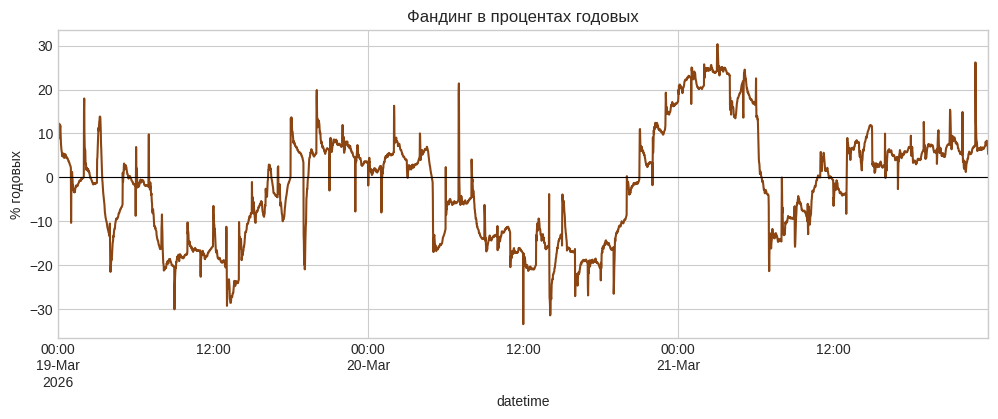

Вывод: 19 и 20 марта средний фандинг отрицательный, 21 марта — положительный. Прибыль и убыток от фандинга нужно считать отдельно от торговли.


In [7]:
funding_1m = funding.set_index('datetime')['annual_pct'].resample('1min').last().dropna()
funding_daily = funding.assign(day=funding['datetime'].dt.date).groupby('day')['annual_pct'].agg(['mean', 'min', 'max'])
funding_daily.columns = ['Среднее, %', 'Минимум, %', 'Максимум, %']
display(funding_daily)
funding_1m.plot(color='saddlebrown', title='Фандинг в процентах годовых')
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel('% годовых')
plt.show()
print('Вывод: 19 и 20 марта средний фандинг отрицательный, 21 марта — положительный. Прибыль и убыток от фандинга нужно считать отдельно от торговли.')

## Распределение доходностей

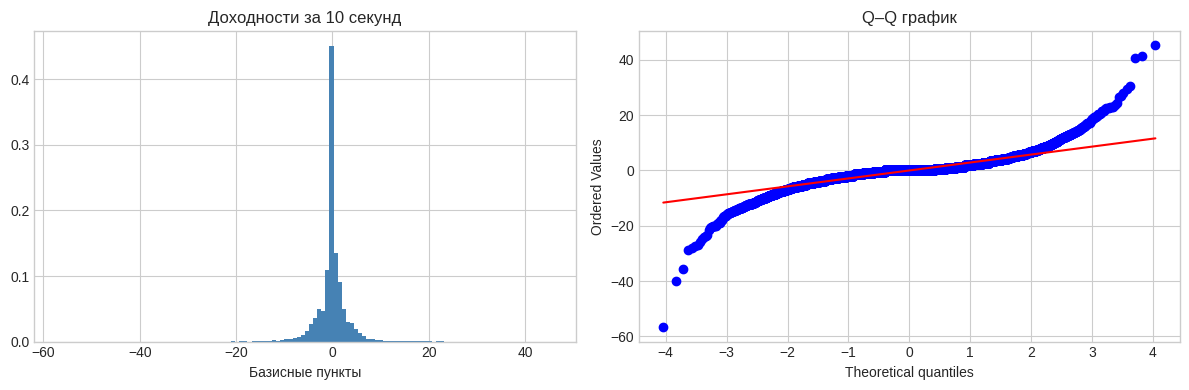

Вывод: на Q–Q графике края сильно отклоняются от прямой. У доходностей тяжёлые хвосты.


In [8]:
sample = returns * 10_000
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(sample, bins=120, density=True, color='steelblue')
axes[0].set_title('Доходности за 10 секунд')
axes[0].set_xlabel('Базисные пункты')
stats.probplot(sample, dist='norm', plot=axes[1])
axes[1].set_title('Q–Q график')
plt.tight_layout()
plt.show()
print('Вывод: на Q–Q графике края сильно отклоняются от прямой. У доходностей тяжёлые хвосты.')

## Тест 1. Стационарность

Расширенный тест Дики — Фуллера:

$$\Delta y_t=\alpha+\gamma y_{t-1}+\sum_i\delta_i\Delta y_{t-i}+\varepsilon_t.$$

**H0:** ряд нестационарен. Уровень значимости: 5%.

In [9]:
def adf_test(name, values):
    statistic, p_value, _, _, _, _ = adfuller(values, maxlag=20, autolag='AIC')
    print(f'{name}: статистика = {statistic:.3f}, p-значение = {p_value:.4g}')
    if p_value < ALPHA:
        print('Решение: ОТВЕРГАЕМ H0. Ряд стационарен.')
    else:
        print('Решение: НЕ ОТВЕРГАЕМ H0. Считаем ряд нестационарным.')
    print()


adf_test('Логарифм цены', np.log(mid_10s))
adf_test('Доходности', returns)

Логарифм цены: статистика = -2.430, p-значение = 0.1333
Решение: НЕ ОТВЕРГАЕМ H0. Считаем ряд нестационарным.

Доходности: статистика = -37.239, p-значение = 0
Решение: ОТВЕРГАЕМ H0. Ряд стационарен.



## Тест 2. Нормальность доходностей

Тест Жарка — Бера:

$$JB=\frac{n}{6}\left(S^2+\frac{(K-3)^2}{4}\right).$$

**H0:** доходности распределены нормально. Уровень значимости: 5%.

In [10]:
jb_stat, jb_p, skewness, kurtosis = jarque_bera(returns)
print(f'Статистика = {jb_stat:.1f}, p-значение = {jb_p:.4g}')
print(f'Асимметрия = {skewness:.3f}, куртозис = {kurtosis:.2f}')
if jb_p < ALPHA:
    print('Решение: ОТВЕРГАЕМ H0. Доходности не имеют нормального распределения.')
else:
    print('Решение: НЕ ОТВЕРГАЕМ H0. Нормальное распределение не противоречит данным.')

Статистика = 371682.7, p-значение = 0
Асимметрия = 0.058, куртозис = 21.55
Решение: ОТВЕРГАЕМ H0. Доходности не имеют нормального распределения.


## Тест 3. Логнормальность размера сделок

Если размер сделки $X$ имеет логнормальное распределение, то $\ln X$ имеет нормальное распределение.

**H0:** размеры сделок имеют логнормальное распределение. Уровень значимости: 5%.

In [11]:
log_size = np.log(trades.loc[trades['size'] > 0, 'size'])
log_jb_stat, log_jb_p, _, _ = jarque_bera(log_size)
print(f'Статистика = {log_jb_stat:.1f}, p-значение = {log_jb_p:.4g}')
if log_jb_p < ALPHA:
    print('Решение: ОТВЕРГАЕМ H0. Размеры сделок не имеют логнормального распределения.')
else:
    print('Решение: НЕ ОТВЕРГАЕМ H0. Логнормальное распределение не противоречит данным.')

Статистика = 2549.9, p-значение = 0
Решение: ОТВЕРГАЕМ H0. Размеры сделок не имеют логнормального распределения.


## Тест 4. Изменчивость волатильности

ARCH-тест:

$$r_t^2=\alpha_0+\sum_{i=1}^{q}\alpha_i r_{t-i}^2+u_t.$$

**H0:** условная дисперсия постоянна. Уровень значимости: 5%.

In [12]:
arch_stat, arch_p, _, _ = het_arch(returns, nlags=20)
print(f'Статистика = {arch_stat:.1f}, p-значение = {arch_p:.4g}')
if arch_p < ALPHA:
    print('Решение: ОТВЕРГАЕМ H0. Волатильность меняется во времени.')
else:
    print('Решение: НЕ ОТВЕРГАЕМ H0. Постоянная дисперсия не противоречит данным.')

Статистика = 4979.4, p-значение = 0
Решение: ОТВЕРГАЕМ H0. Волатильность меняется во времени.


## Влияние обвала

Сравним доходности со всем периодом и без выделенного окна.

In [13]:
without_crash = returns[(returns.index < start) | (returns.index > end)]
comparison = pd.DataFrame({
    'Весь период': [returns.std() * 10_000, stats.kurtosis(returns, fisher=False)],
    'Без обвала': [without_crash.std() * 10_000, stats.kurtosis(without_crash, fisher=False)],
}, index=['Стандартное отклонение, б.п.', 'Куртозис'])
display(comparison)
print('Вывод: обвал усиливает хвосты, но не является единственной причиной ненормальности. Из основной исторической проверки его не удаляем.')

,Весь период,Без обвала
"Стандартное отклонение, б.п.",3.164304,3.052882
Куртозис,21.551298,13.929670


Вывод: обвал усиливает хвосты, но не является единственной причиной ненормальности. Из основной исторической проверки его не удаляем.


## Итог

1. Исходная цена нестационарна, доходности стационарны.
2. Доходности не распределены нормально.
3. Размеры сделок не распределены логнормально.
4. Волатильность меняется во времени.
5. Давление хорошо угадывает сторону ближайшего движения на 0.3–1 секунде, но не умеет предсказывать, когда движение произойдёт, и плохо оценивает его размер.
6. Обвал в конце оставляем в основной исторической проверке.
7. Фандинг меняет знак и должен входить в расчёт прибыли и убытка.